# Trading Strategy & Regime Testing

**Purpose.** This notebook enables testing trading strategies on different assets, performance analysis, visual representation of positions and P&L and optimization of trend and volatility regime parameters.

**How to read.**
- Each code cell is preceded by a Markdown explanation of what it does.
- The core sections of this notebook are data loading, preprocessing, signal generation, strategy/backtesting, evaluation, and visualization.
- The strategies tested in this notebook use the optimal parameters obtained from optimizing Technical indicator's parameters. The code for this optimization is provided elsewhere.


### Imports required libraries:


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from abc import ABC, abstractmethod
from itertools import combinations
from tqdm import tqdm
import itertools
#from mpi4py import MPI
from collections import defaultdict
import copy
import warnings
import os
warnings.filterwarnings('ignore')

### Loads data from files or external sources into memory. Defines helper function(s): load_data, _clean_data, load_data to ensure trading strategy/backtest workflow. Declares custom class(es): DataLoader, CSVLoader, BloombergLoader, TradingViewLoader



In [2]:
# Define custom class: DataLoader
class DataLoader(ABC):
    @abstractmethod
    def load_data(self, **kwargs):
        pass

# Define custom class: CSVLoader. For credibility purposes, We only use the csv loader since we get the OHLC date from Bloomberg.
class CSVLoader(DataLoader):
    def load_data(self, file_path, index_col=0, type = 'csv', columns_map=None):
        if type == 'csv':    
            df = pd.read_csv(file_path, index_col=index_col)
            if columns_map:
                df = df.rename(columns=columns_map).iloc[::-1]
            return self._clean_data(df)
        elif type == 'xlsx':
            df = pd.read_excel(file_path, index_col=index_col)
            if columns_map:
                df = df.rename(columns=columns_map)
            return self._clean_data(df)

    # Regarding this function, we won't be filling missing values and removing duplicates as it wouldn't account for only trading days.
    def _clean_data(self, df):
        #df = df.asfreq('D')
        #df = df.ffill().bfill()
        #df = df[~df.index.duplicated(keep='first')]
        return df

class BloombergLoader(DataLoader):
    def load_data(self, symbol, fields, start_date, end_date):
        pass

class TradingViewLoader(DataLoader):
    def load_data(self, widget):
        pass

### The following computes Technical Indicators (SMA, EMA, RSI, MACD, PSAR, Stochastic, Bollinger Bands) used in the signal

> **Scope.** These indicators transform raw OHLCV time series into smoother or bounded signals that help detect trend, momentum, and volatility regimes. All signals below must be computed on the **same timeframe** as the strategy.

---

#### Simple Moving Average (SMA)

- **What it is:** Unweighted average of the last *n* closes.
- **Formula:**
  
  $$ \mathrm{SMA}_n(t) = \frac{1}{n}\sum_{i=0}^{n-1} \text{Close}(t-i) $$
- **Parameters:** `n` (window length, e.g., 20, 50, 200).
- **Interpretation:** Smooths price; longer windows = smoother/laggier.
- **Typical signals:**
  - **Price vs SMA:** Bullish if Close crosses above SMA; bearish if below.
  - **SMA crossover:** Fast SMA (e.g., 50) crossing above Slow SMA (e.g., 200) = bullish (“golden cross”); opposite = bearish (“death cross”).
- **Notes:** Sensitive to outliers; lag increases with window length.

---

#### Exponential Moving Average (EMA)

- **What it is:** Recency-weighted average; reduces lag vs SMA.
- **Recursive form:**
  
$$  \alpha=\frac{2}{n+1},\quad \mathrm{EMA}_n(t)=\alpha \cdot \text{Close}(t)+(1-\alpha)\cdot \mathrm{EMA}_n(t-1) $$
- **Parameters:** `n` (span, e.g., 12, 26).
- **Interpretation:** Reacts faster to new information than SMA.
- **Typical signals:**
  - **Price vs EMA:** Close crossing EMA.
  - **EMA crossover:** Fast EMA above Slow EMA = bullish momentum; below = bearish.
- **Notes:** Choice of `n` strongly affects responsiveness vs noise.

---

#### Relative Strength Index (RSI)

- **What it is:** Bounded momentum oscillator (0–100) comparing average gains vs losses.
- **Computation (Wilder’s smoothing, period *n*):**
  
  1. $ U_t=\max(\Delta \text{Close}_t,0),\quad D_t=\max(-\Delta \text{Close}_t,0) $
  2. $ \text{AvgGain}_t=\frac{\text{AvgGain}_{t-1}\cdot(n-1)+U_t}{n} , \text{AvgLoss}_t=\frac{\text{AvgLoss}_{t-1}\cdot(n-1)+D_t}{n} $
  3. $ RS_t=\frac{\text{AvgGain}_t}{\text{AvgLoss}_t} $
  4. $ \mathrm{RSI}_t=100-\frac{100}{1+RS_t} $
- **Parameters:** `n` (e.g., 14), overbought/oversold (e.g., 70/30).
- **Interpretation:** High RSI = recent gains dominate; low RSI = losses dominate.
- **Typical signals:**
  - **Thresholds:** RSI > 70 (overbought), RSI < 30 (oversold). Mean-reversion often sells >70, buys <30.
  - **Crossbacks:** Buy when RSI crosses up through 30; sell when it crosses down through 70.
  - **Divergence:** Price makes new high but RSI doesn’t (bearish divergence), and vice versa.
- **Notes:** In strong trends, RSI can “stick” in extreme zones—trend filters help.

---

#### Moving Average Convergence/Divergence (MACD)

- **What it is:** Trend/momentum indicator from differences of EMAs.
- **Computation (common: 12/26/9):**
  $$ \mathrm{MACD}_t = \mathrm{EMA}_{12}(t) - \mathrm{EMA}_{26}(t),\quad
  \text{Signal}_t = \mathrm{EMA}_9(\mathrm{MACD}_t),\quad
  \text{Histogram}_t = \mathrm{MACD}_t - \text{Signal}_t $$
- **Parameters:** fast EMA, slow EMA, signal EMA (e.g., 12, 26, 9).
- **Interpretation:** Positive MACD = bull bias; negative = bear bias. Histogram shows momentum change.
- **Typical signals:**
  - **Line cross:** MACD crossing above Signal = buy; below = sell.
  - **Zero cross:** MACD crossing above/below 0 confirms trend direction.
  - **Divergence:** Momentum failing while price trends = caution.
- **Notes:** Faster settings increase whipsaws; combine with volatility filters.

---

#### Parabolic SAR (PSAR)

- **What it is:** Trend-following stop/“trailing dot” that accelerates with trend persistence.
- **Core update (long example):**
  
  - Start with an initial **SAR** below price, set **EP** (extreme point) to highest high since entry, and **AF** (acceleration factor) to a small value (e.g., 0.02).
  - Each step:
$$ \mathrm{SAR}_{t} = \mathrm{SAR}_{t-1} + AF \cdot (EP - \mathrm{SAR}_{t-1}) $$
    If a new high occurs, update \(EP\) and increment \(AF\) (up to a cap, e.g., 0.2).
  - Flip to short when SAR would penetrate price; then mirror logic with lowest lows.
- **Parameters:** `af_start` (e.g., 0.02), `af_step` (e.g., 0.02), `af_max` (e.g., 0.2).
- **Interpretation:** Dots below price = long trend; above = short trend.
- **Typical signals:**
  - **Flip:** When SAR switches sides (below→above or above→below), reverse or exit.
  - **Trail stop:** Use SAR as trailing stop in trend strategies.
- **Notes:** Very reactive in choppy markets—consider trend filter (e.g., EMA slope).

---

#### Stochastic Oscillator (SO)

- **What it is:** Measures close position relative to recent high/low range; momentum/overbought-oversold oscillator.
- **Raw %K (period *n*):**
  
$$  \%K_t = 100 \cdot \frac{\text{Close}_t - \text{LowestLow}_n}{\text{HighestHigh}_n - \text{LowestLow}_n} $$
- **%D:** Moving average of %K (e.g., 3-period SMA). Slow Stochastic further smooths %K before %D.
- **Parameters:** `n` (lookback, e.g., 14), `%K_smooth` (e.g., 3), `%D` (e.g., 3), thresholds (80/20).
- **Interpretation:** High values = closes near recent highs; low = near recent lows.
- **Typical signals:**
  - **Crossovers:** %K crossing above %D below 20 = buy; crossing below %D above 80 = sell.
  - **Range trading:** Fade moves into 80/20 zones in sideways markets.
- **Notes:** Very sensitive to range compression; combine with volatility or trend filter.

---

#### Bollinger Bands (BB)

- **What it is:** Volatility bands around a moving average (usually SMA). Band width expands/contracts with volatility.
- **Computation (period *n*, stdev *k*):**
  
$$
  \text{Middle}_t = \mathrm{SMA}_n(t),\quad
  \text{Upper}_t = \text{Middle}_t + k\cdot \sigma_n(t),\quad
  \text{Lower}_t = \text{Middle}_t - k\cdot \sigma_n(t)
$$
  where \(\sigma_n(t)\) is the rolling standard deviation of Close over *n*.
- **Parameters:** `n` (e.g., 20), `k` (e.g., 2).
- **Interpretation:** Price touching/closing outside bands indicates strong move; band squeeze signals low-vol regimes.
- **Typical signals:**
  - **Mean-reversion:** Short near Upper band; long near Lower band (works best in ranges).
  - **Breakout:** Enter in the direction of a close outside a band when accompanied by volume/momentum confirmation.
  - **Squeeze:** When band width is at multi-period lows, prepare for expansion/breakout.
- **Notes:** Bands assume roughly normal dispersion locally—fat tails can produce persistent band walks in trends.

---

### Practical integration into a trading signal

- **Confluence:** Require agreement (e.g., EMA fast > EMA slow **and** MACD > 0 **and** RSI > 50) before entering.
- **Regime filters:** Use trend (EMA slope, MACD sign) to decide whether to apply **mean-reversion** (RSI/BB/Stoch) or **trend-following** (crossovers, PSAR).
- **Warm-up:** Drop first `max(window)` bars across indicators to avoid partial windows/`NaN`s.
- **Parameter sanity:** Start from conventional defaults (SMA20/50/200, EMA12/26, RSI14 70/30, MACD 12-26-9, Stoch 14-3-3, BB 20×2, PSAR 0.02/0.02/0.2) and tune only with robust validation to limit overfitting.



In [3]:
# Define abstract class: TechnicalIndicator. Each technical indicator inherits from this class.
class TechnicalIndicator(ABC):
    def __init__(self, window,indicator_type, source='close'):
        self.window = window
        self.indicator_type = indicator_type
        self.source = source
    
    @abstractmethod
# Define helper function: compute
    def compute(self, data):
        pass

# Define custom class: SMA
class SMA(TechnicalIndicator):
    def __init__(self, window):
        super().__init__(window, 'trend')
    def compute(self, data):
# SMA signal line
        return data[self.source].rolling(self.window).mean()

# Define custom class: EMA
class EMA(TechnicalIndicator):
    def __init__(self, window):
        super().__init__(window, 'trend')
    def compute(self, data):
# EMA signal line
        return data[self.source].ewm(span=self.window, adjust=False).mean()

# Define custom class: RSI
class RSI(TechnicalIndicator):
    def __init__(self, window):
        super().__init__(window, 'momentum')
    def compute(self, data):
        delta = data[self.source].diff()
        gain = delta.where(delta > 0, 0)
        loss = -delta.where(delta < 0, 0)
        avg_gain = gain.rolling(self.window).mean()
        avg_loss = loss.rolling(self.window).mean()
        rs = avg_gain / avg_loss
# RSI signal line
        return 100 - (100 / (1 + rs))

# Define custom class: MACD
class MACD:
    def __init__(self, fast=12, slow=26, signal=9):
        self.indicator_type = 'trend'
        self.fast = fast
        self.slow = slow
        self.signal = signal
    
    def compute(self, data):
        fast_ema = data['close'].ewm(span=self.fast, adjust=False).mean()
        slow_ema = data['close'].ewm(span=self.slow, adjust=False).mean()
# MACD line
        macd_line = fast_ema - slow_ema
# signal line
        signal_line = macd_line.ewm(span=self.signal, adjust=False).mean()
# difference
        diff = macd_line - signal_line
# Return the MACD line, signal line, and difference
        return macd_line, signal_line, diff
    
    
# Define custom class: ParabolicSAR (Parabolic Stop and Reverse)
class ParabolicSAR:
    def __init__(self, initial_af=0.02, max_af=0.2, step=0.01):
        self.initial_af = initial_af
        self.max_af = max_af
        self.step = step
        self.reset()
# reset the state variables
    def reset(self):
        self.trend = None    
        self.af = self.initial_af 
        self.ep = None           
        self.sar = None
        self.signals = [] 
        self.historical_sar = []
        self.prev_high = None
        self.prev_low = None
# update the state variables
    def update(self, high, low):
        signal = 0
        
# Conditional logic
        if self.trend is None:
            self._initialize(high, low)
            self.signals.append(0)
            return 0

        reversal = False
        new_sar = self._calculate_next_sar()
        prev_trend = self.trend

# Check trend reversal
        if self.trend == 'up':
            if low < new_sar:
                reversal = True
        else:
            if high > new_sar:
                reversal = True

# Handle trend reversal
        if reversal:
            self._reverse_trend(high, low, new_sar)
            signal = 1 if prev_trend == 'down' else -1
        else:
            self._continue_trend(high, low, new_sar)

        self.historical_sar.append(self.sar)
        self.signals.append(signal)
# Parabolic SAR signal
        return signal
    
# Initialize the state variables
    def _initialize(self, high, low):
        self.trend = 'up' if high > low else 'down'
        self.ep = high if self.trend == 'up' else low
        self.sar = low if self.trend == 'up' else high
        self.prev_high = high
        self.prev_low = low
        self.historical_sar.append(self.sar)

# Calculate the next SAR value based on the current trend
    def _calculate_next_sar(self):
        if self.trend == 'up':
            return self.sar + self.af * (self.ep - self.sar)
        return self.sar - self.af * (self.sar - self.ep)

# Rzeverse the trend and update the state variables
    def _reverse_trend(self, high, low, new_sar):
        self.trend = 'down' if self.trend == 'up' else 'up'
        self.sar = self.ep 
        self.af = self.initial_af
        self.ep = low if self.trend == 'up' else high

# Handle continuation of the trend and update the state variables
    def _continue_trend(self, high, low, new_sar):
        self.sar = new_sar
        if self.trend == 'up':
            if high > self.ep:
                self.ep = high
                self.af = min(self.af + self.step, self.max_af)
        else:
            if low < self.ep:
                self.ep = low
                self.af = min(self.af + self.step, self.max_af)

# Get the signals generated by the Parabolic SAR. In this class we generate trading signals directly without using SignalGenerator class. 
    def get_signals(self, index=None):
        if index is not None and len(index) == len(self.signals):
            return pd.Series(self.signals, index=index, name='signal')
        return pd.Series(self.signals, name='signal')
    

# Define custom class: StochasticOscillator
class StochasticOscillator:
    def __init__(self, data=None, k_period=14, d_period=5, smoothing=1):
        self.data = data
        self.k_period = k_period
        self.d_period = d_period
        self.smoothing = smoothing
        self._validate_parameters()
        
        self._k_values = None
        self._d_values = None
        self.signals = None

# Check the validity of the smoothing parameters
    def _validate_parameters(self):
        if self.k_period < 0 or self.d_period < 0:
            raise ValueError("Periods must be positive integers")
        if self.smoothing not in [0, 1, 2, 3]:
            raise ValueError("Smoothing must be 0, 1, 2, or 3")

    def compute(self):
        if self.data is None:
            raise ValueError("No data provided")

        low_min = self.data['low'].rolling(self.k_period).min()
        high_max = self.data['high'].rolling(self.k_period).max()
        
        k = 100 * (self.data['close'] - low_min) / (high_max - low_min)
        k = k.replace([np.inf, -np.inf], np.nan).ffill()
        
# %K line
        if self.smoothing == 0:
            k = k.rolling(1).mean()
        if self.smoothing >= 1:
            k = k.rolling(self.d_period).mean()
        if self.smoothing >= 2:
            k = k.rolling(self.d_period).mean()
        if self.smoothing == 3:
            k = k.rolling(self.d_period).mean()
        
        self._k_values = k
# %D line
        self._d_values = k.rolling(self.d_period).mean()
        return self

# Generate trading signals based on the Stochastic Oscillator values
    def generate_signals(self, overbought=80, oversold=20):
        if self._k_values is None or self._d_values is None:
            raise ValueError("Compute Stochastic values first")

        signals = pd.Series(0, index=self.data.index)
        # Generate bullish and bearish signals
        bullish_cross = (self._k_values > self._d_values) & \
                        (self._k_values.shift(1) <= self._d_values.shift(1)) & \
                        (self._k_values < oversold)
        
        bearish_cross = (self._k_values < self._d_values) & \
                         (self._k_values.shift(1) >= self._d_values.shift(1)) & \
                         (self._k_values > overbought)
        
        signals[bullish_cross] = 1
        signals[bearish_cross] = -1
        
        self.signals = signals
        return signals

# Define custom class: BollingerBands
class BollingerBands:
    def __init__(self, data, window=38, num_std=2):
        self.data = data
        self.window = window
        self.num_std = num_std
        self.middle_band = None
        self.upper_band = None
        self.lower_band = None
        self.percent_b = None
        self.bandwidth = None
        self.signals = None
# compute middle, upper, and lower bands
    def compute(self):
        self.middle_band = self.data['close'].rolling(self.window).mean()
        std = self.data['close'].rolling(self.window).std()
        self.upper_band = self.middle_band + (std * self.num_std)
        self.lower_band = self.middle_band - (std * self.num_std)
        # get bandwidth and %B values
        band_width = self.upper_band - self.lower_band
        self.percent_b = (self.data['close'] - self.lower_band) / band_width.replace(0, np.nan)
        self.bandwidth = band_width / self.middle_band
        
        return self

# Generate trading signals based on the Bollingr Bands values
    def generate_signals(self, squeeze_threshold=0.3, squeeze_lookback=20):
        if self.middle_band is None:
            self.compute()

        signals = pd.Series(0, index=self.data.index)
        
        upper_cross = (self.data['close'] > self.upper_band).astype(int).diff()
        lower_cross = (self.data['close'] < self.lower_band).astype(int).diff()
        
        signals[upper_cross == -1] = -1
        signals[lower_cross == -1] = 1
        # Check if there's a squeeze period
        squeeze_level = self.bandwidth.rolling(squeeze_lookback).quantile(squeeze_threshold)
        in_squeeze = (self.bandwidth < squeeze_level).fillna(False)
        
        squeeze_buy = in_squeeze & (self.data['close'] > self.middle_band)
        signals[squeeze_buy & ~in_squeeze.shift(1).fillna(False)] = 1
        
        squeeze_sell = in_squeeze & (self.data['close'] < self.middle_band)
        signals[squeeze_sell & ~in_squeeze.shift(1).fillna(False)] = -1
        
        self.signals = signals
        return signals

### Average True Range (ATR) — volatility measure used for stops, position sizing, and regime filters

> **Scope.** ATR quantifies *absolute* price volatility by averaging **True Range (TR)** over a rolling window. It is independent of direction (up/down) and reacts to gaps. In this notebook, ATR is used to (i) scale stops/targets, (ii) size positions by risk, and (iii) filter regimes (quiet vs. volatile).

---

#### Definitions

**True Range (TR)** at time \(t\) uses today’s high/low and yesterday’s close:
$$
\mathrm{TR}_t = \max\Big(
\; \mathrm{High}_t - \mathrm{Low}_t,\;
\big|\mathrm{High}_t - \mathrm{Close}_{t-1}\big|,\;
\big|\mathrm{Low}_t - \mathrm{Close}_{t-1}\big|
\Big)
$$

**Average True Range (ATR)** with Wilder’s smoothing over period \(n\) (default \(n=14\)):
- **Initialization:** $\mathrm{ATR}_n = \text{SMA}_n(\mathrm{TR})$ (simple average of the first \(n\) TR values)
- **Recursive update (Wilder):**
$$
\mathrm{ATR}_t = \frac{(n-1)\cdot \mathrm{ATR}_{t-1} + \mathrm{TR}_t}{n}
$$

> **Alternative (EMA form):** with $\alpha=\frac{2}{n+1}$,
$$
\mathrm{ATR}_t = \alpha\cdot \mathrm{TR}_t + (1-\alpha)\cdot \mathrm{ATR}_{t-1}
$$
Both are acceptable; Wilder’s is the canonical version.

---

#### Parameters

- `n` — lookback (typical: 14; slower 20–30; faster 5–10)
---

#### Interpretation

- Larger ATR ⇒ wider daily range / more volatile regime.
- ATR is **direction-agnostic** (rising in both uptrends and downtrends if ranges expand).
- Reacts to **gaps** by design (via $|\mathrm{High}_t-\mathrm{Close}_{t-1}|$ and $|\mathrm{Low}_t-\mathrm{Close}_{t-1}|$).

---

#### Practical notes

- **Warm-up:** The first \(n\) bars are needed to seed ATR; expect `NaN` until then.
- **No look-ahead:** Always use $\mathrm{Close}_{t-1}$ when computing $\mathrm{TR}_t$.
- **Missing OHLC:** Ensure `High ≥ Low`, and previous `Close` exists; forward-fill carefully or drop bad rows.
- **Cross-asset comparability:** Prefer **ATR%** for instruments with very different price levels.
- **Sensitivity:** Smaller `n` ⇒ faster but noisier ATR; larger `n` ⇒ smoother but laggier.
- **Outliers/gaps:** ATR will jump on extreme gaps (intended). If needed, cap TR (e.g., winsorize) *only if justified* by data quality.
- **Timeframe:** ATR is timeframe-specific; do not mix daily ATR with intraday stops unless explicitly designed.




In [4]:
# Define custom class: ATR
class ATR:
    def __init__(self, window=14):
        self.window = window
        self._validate_window()
        
    def _validate_window(self):
        if not isinstance(self.window, int) or self.window < 1:
            raise ValueError("Window must be positive integer")

# Compute the Average True Range (ATR) using Wilder's smoothing method
    def compute(self, data):
        self._check_ohlc(data)
        
        tr = self._true_range(data)
        atr = self._smooth(tr)
        
        return atr.rename(f'ATR_{self.window}')

# Get the true range values
    def _true_range(self, data):
        prev_close = data['close'].shift(1).ffill()
        
        tr1 = data['high'] - data['low']
        tr2 = (data['high'] - prev_close).abs()
        tr3 = (data['low'] - prev_close).abs()
        
        return pd.concat([tr1, tr2, tr3], axis=1).max(axis=1)

# Apply Wilder's smoothing method to the true range values
    def _smooth(self, tr):
        sma_initial = tr.rolling(self.window).mean()[:self.window]
        ema_rest = tr[self.window:].ewm(alpha=1-(1/self.window), adjust=False).mean()
        
        return pd.concat([sma_initial, ema_rest])

# Xheck if the OHLC data contains the required columns
    def _check_ohlc(self, data):
        required = ['open','high', 'low', 'close']
        missing = [col for col in required if col not in data.columns]
        if missing:
            raise ValueError(f"Données OHLC manquantes : {missing}")

### `SignalGenerator` & `SignalValidator` — compact overview

**Purpose.** Build trade **signals** (buy=+1, sell=−1, flat=0) from pre-computed indicators, with a **primary** trigger and optional **validator** votes. Supports simple **regime filters** and **ATR-based** risk hooks.

---

#### Inputs & outputs
- **Input**: OHLC DataFrame with required columns (`Open, High, Low, Close`) **plus** the indicators you compute (e.g., `EMA_fast/slow`, `RSI`, `MACD`, `PSAR`, `%K/%D`, `BB_upper/lower`, `ATR`).
- **Output**: DataFrame with at least:
  - `signal` ∈ {−1, 0, +1}
- `Visualisation` function to plot positions in price chart
---

#### Core parameters
- `primary`: main rule (e.g., `ema_cross`, `macd_cross`, `rsi_threshold`, `psar_flip`, `stoch_cross`, `bb_touch`).
- `validators`: list of confirming rules (equal weight).
- `vote_min`: minimum confirms (e.g., 2) **in addition** to the primary.
- `regime_filter`: e.g., trend (`EMA_fast > EMA_slow`) or volatility (`ATR%` threshold).

---

#### Workflow (high level)
1. **Raw triggers** per rule (True/False):
   - `ema_cross`: `EMA_fast` crosses above/below `EMA_slow`.
   - `macd_cross`: `MACD` crosses `Signal` (zero-line optional).
   - `rsi_threshold`: cross up through 30 (buy) / down through 70 (sell).
   - `psar_flip`: PSAR switches side relative to price.
   - `stoch_cross`: `%K` cross `%D` below 20 (buy) / above 80 (sell).
   - `bb_touch`: Close < lower (mean-revert buy) / > upper (sell) or breakout mode.
2. **Regime filter** : Compare ATR (or ATR%) to its rolling mean:
     - **Quiet regime:** ATR below threshold → favor mean-reversion entries.
     - **Volatile regime:** ATR above threshold → favor trend/breakout entries, widen stops.

---
3. **Voting**: fire a signal when **primary** is True **and** `sum(validators) ≥ vote_min`.

---

#### Edge cases & assumptions
- Drop/ignore rows with `NaN` indicators (warm-up windows).
- Ensure **no look-ahead** (use prior bars for cross checks).
- Handle duplicate timestamps and out-of-order data before calling.

---

In [5]:

# Define custom class: SignalGenerator
class SignalGenerator:
    @staticmethod
# Define crossover function
    def crossover(series1, series2):
        signals = pd.Series(0, index=series1.index)
        series11 = series1.copy()
        series22 = series2.copy()
        signals[(series11.shift(1) < series22.shift(1)) & (series11 > series22)] = 1
        signals[(series11.shift(1) > series22.shift(1)) & (series11 < series22)] = -1
        return signals
# Define threshold function
    @staticmethod
    def threshold(rsi_series, oversold=30, overbought=70):
        signals = pd.Series(0, index=rsi_series.index)
        # oversold and overbought signals
        signals[rsi_series < oversold] = 1
        signals[rsi_series > overbought] = -1
        return signals
    @staticmethod
# Define combine_signals to get ensemble voting signals
    def combine_signals(signals_list, min_confirmation=2):
        combined = pd.DataFrame(signals_list).T.sum(axis=1)
        confirmation = pd.DataFrame(signals_list).T.abs().sum(axis=1)
        
        final_signal = pd.Series(0, index=combined.index)
        final_signal[(combined > 0) & (confirmation >= min_confirmation)] = 1
        final_signal[(combined < 0) & (confirmation >= min_confirmation)] = -1
        return final_signal
            
# Define regime_combined to check for different regimes and combine signals
# This function combines multiple signals based on different regimes (trend, volatility) and weights.
# The wheights are defined as a list of dictionaries, where each dictionary contains the weights for different indicators.
    def regime_combined(self, df, weights):
        signals = pd.Series(0, index=df.index)
        theta_enter = weights[1]
        eps_trend = weights[2]
        # Volatility regime threshold
        atr_mean = df['atr'].rolling(20).mean()
        atr_std  = df['atr'].rolling(20).std()
        vol_level = atr_mean + atr_std
        # check if volatility and trend regimes
        for i in range(1, len(df)):
            row = df.iloc[i]
            vol_regime   = 'high' if row['atr'] > vol_level.iloc[i] else 'low'
            trend_slope  = row['sma50'] - row['sma200']
            trend_regime = 'trend' if abs(trend_slope) > eps_trend else 'range'
            
            votes = []
            
# Compute signals based on trend regimes
            if trend_regime == 'trend':
                votes += [
                    weights[0]['EMA']   * row.get('EMA_sig', 0),
                    weights[0]['MACD']  * row.get('MACD_sig', 0),
                    weights[0]['PSAR']  * row.get('PSAR_sig', 0)
                ]
            else:
                votes += [
                    weights[0]['RSI']   * row.get('RSI_sig', 0),
                    weights[0]['SO']    * row.get('SO', 0)
                ]
            
# Compute signals based on volatility regimes
            if vol_regime == 'high':
                votes.append(weights[0]['BB'] * row.get('BB_sig', 0))
            
            S = sum(votes)
            
# Generate trading signals based on the combined votes
            if S >= theta_enter:
                sig =  1
            elif S <= -theta_enter:
                sig = -1
            else:
                sig =  0
            signals.iat[i] = sig
        return signals

# Define custom class: SignalValidator
class SignalValidator:
    @staticmethod
    # Confirm volatility function
    def confirm_volatility(signals, atr, threshold=1.5):
        return signals * (atr > threshold)
    
    @staticmethod
# Plot signals function
    def plot_signals(data, signals):
        buy_signals = signals[signals == 1].index
        sell_signals = signals[signals == -1].index
        
        data['close'].plot(figsize=(15, 7), color='blue')
        data.loc[buy_signals, 'close'].plot(ls='', marker='^', markersize=7, color='g', label='Buy Signal')
        data.loc[sell_signals, 'close'].plot(ls='', marker='v', markersize=7, color='r', label='Sell Signal')
        plt.legend()
        plt.show()

# Define helper function: plot_positions
# This function plots the positions on the price chart, showing validated buy/sell signals and active positions.
# It uses the data, signals, and position log (defined later on) to visualize the trading activity.
    def plot_positions(self, data, signals,position_log):
        
        # Create plot
        plt.figure(figsize=(15, 7))
        data.index = pd.to_datetime(data.index)
        ax = data['close'].plot(color='black', label='Close Price')
        
        # Initialize position tracking
        current_position = None
        position_start = None
        valid_positions = [p for p in position_log if p is not None]
        
        # Track actual entry points from backtest results
        actual_buy_dates = [p['entry_date'] for p in valid_positions if p['direction'] == 1]
        actual_sell_dates = [p['entry_date'] for p in valid_positions if p['direction'] == -1]

        # 1. Plot validated signals from backtest
        data.loc[actual_buy_dates, 'close'].plot(
            ax=ax, ls='', marker='^', markersize=9, 
            color='lime', markerfacecolor='none', markeredgewidth=1.5,
            label='Validated Buy'
        )
        data.loc[actual_sell_dates, 'close'].plot(
            ax=ax, ls='', marker='v', markersize=9,
            color='red', markerfacecolor='none', markeredgewidth=1.5,
            label='Validated Sell'
        )

        # 2. Color active positions from backtest log
        current_direction = None
        position_start = None
        
        for i, pos in enumerate(position_log):
            date = data.index[i]
            
            if pos:
                # New position started
                if not current_direction:
                    current_direction = pos['direction']
                    position_start = date
            else:
                # Position closed
                if current_direction:
                    color = 'green' if current_direction == 1 else 'red'
                    ax.axvspan(position_start, data.index[i-1], 
                            color=color, alpha=0.2)
                    current_direction = None

        # Handle any open position at end
        if current_direction:
            ax.axvspan(position_start, data.index[-1],
                    color='green' if current_direction == 1 else 'red',
                    alpha=0.2)
        # 3. Original signal markers (transparent)
        data.loc[signals[signals == 1].index, 'close'].plot(
            ax=ax, ls='', marker='^', markersize=7,
            color='blue', alpha=0.3, label='Raw Buy Signals'
        )
        data.loc[signals[signals == -1].index, 'close'].plot(
            ax=ax, ls='', marker='v', markersize=7,
            color='blue', alpha=0.3, label='Raw Sell Signals'
        )

        plt.title('Price Chart with Validated Positions')
        plt.legend()
        plt.show()

### `PortfolioManager`  — class overview

1. **Volatility-scaled stop loss / take profit**
   - **Initial stop (long)**:
     $$
     \text{Stop} = \text{Entry} - k \cdot \mathrm{ATR}
     \quad\text{(short: Entry} + k\cdot \mathrm{ATR})
     $$
     with $k \in [1.5, 3]$ commonly.
   - **Targets:** symmetric or asymmetric multiples of ATR (e.g., $+2\cdot \mathrm{ATR}$).

2. **Trailing stop (Chandelier Exit—example)**
   - **Long:**
     $$
     \text{Trail} = \max\_{\text{since entry}}(\mathrm{High}) - k \cdot \mathrm{ATR}
     $$
   - **Short:**
     $$
     \text{Trail} = \min\_{\text{since entry}}(\mathrm{Low}) + k \cdot \mathrm{ATR}
     $$
   - Tightens automatically as volatility contracts or as price moves in favor.

3. **Position sizing by risk (volatility parity within a strategy)**
   - With account equity $E$ and per-trade risk fraction $r$ (e.g., 1%), define **risk per trade**:
     $$
     R = r \cdot E
     $$
   - **Unit risk** (distance to stop): $D = k \cdot \mathrm{ATR}$.
   - **Position size (units/contracts):**
     $$
     \text{Size} = \left\lfloor \frac{R}{D} \right\rfloor
     $$
   - This keeps expected loss per trade ≈ $R$ regardless of volatility regime.

4. **Breakout channels**
   - Upper/Lower envelopes based on Entry price ± $k\cdot \mathrm{ATR}$:
     $$
     \text{Upper} = \mathrm{P}_{entry} + k\cdot \mathrm{ATR},\quad
     \text{Lower} = \mathrm{P}_{entry} - k\cdot \mathrm{ATR}
     $$
   - Use closes beyond these bands to confirm breakouts with volatility context.


In [6]:
# Define custom class: PortfolioManager
class PortfolioManager:
# Define helper function: __init__
    def __init__(self, initial_capital, risk_per_trade=0.05, atr_multiplier=2):
        self.initial_capital = initial_capital
        self.risk_per_trade = risk_per_trade
        self.atr_multiplier = atr_multiplier
    
# Define calculate_position_size function
# This function calculates the position size based on the current price, ATR, and risk per trade.
    def calculate_position_size(self, price, atr): 
        risk_amount = self.initial_capital * self.risk_per_trade
        return risk_amount / (atr * self.atr_multiplier)
    
# Define dynamic_stop_loss function
    def dynamic_stop_loss(self, entry_price, atr, direction,stp_multiplier):
        if direction == 1:
            return entry_price - (atr * stp_multiplier)
        else:
            return entry_price + (atr * stp_multiplier)
# Define dynamic_take_profit function
    def dynamic_take_profit(self, entry_price, atr, direction,tp_multiplier):
        if direction == 1:
            return entry_price + (atr * tp_multiplier)
        else:
            return entry_price - (atr * tp_multiplier)

### `Backtester` — class overview

**Purpose.** Orchestrates the end-to-end pipeline: load price data, precompute indicator series, interactively select indicators to combine, validate signals, run a simple position-based backtest, and report/plot results. It delegates data loading, signal ops, validation, and risk maths to other classes but does re-implement them.

**Main components:**

- **`Initialization`**  
  Initializes the backtester with:
  - `df`: Historical price data (OHLC and other features).
  - `signals`: Generated trading signals to be tested.

- **`run_backtest`**  
  Executes the backtest by:
  - Iterating over the dataset.
  - Entering and exiting trades according to the signals.
  - Tracking portfolio value, PnL, and returns.

- **`calculate_performance`**  
  Summarizes results by:
  - Computing total return.
  - Calculating performance metrics such as win rate and average trade return.
  - Returning a performance report for evaluation.

- **`plot_results`**  
  Produces a performance chart showing:
  - Equity curve (portfolio value over time).
  - Buy and sell markers on the price chart for visual inspection.

This class provides a complete framework to assess the effectiveness of a trading strategy before deploying it in real markets.



In [7]:
# Define custom class: Backtester
class Backtester:
    def __init__(self, weights, initial_capital=10_000):
        self.weights = weights
        self.initial_capital = initial_capital
        self.portfolio = PortfolioManager(initial_capital)
        self.data_loader = CSVLoader()
        self.signals = SignalGenerator()
        self.validator = SignalValidator()
        
    def load_data(self, file_path,type):
        if type == 'csv':
            self.data = self.data_loader.load_data(
                file_path=file_path,
                columns_map={
                    'Price': 'close',
                    'High': 'high',
                    'Low': 'low',
                    'Open': 'open',
                    'Vol.': 'volume'
                }
            ,type = type)
        elif type == 'xlsx':
            self.data = self.data_loader.load_data(
                file_path=file_path,
                columns_map={
                    'PX_LAST': 'close',
                    'PX_HIGH': 'high',
                    'PX_LOW': 'low',
                    'PX_OPEN': 'open'
                }
            ,type = type)
    # precompute indicators with optimal parameters
    def precompute_indicators(self):
        self.data['sma50'] = SMA(50).compute(self.data)
        self.data['sma200'] = SMA(200).compute(self.data)
        self.data['rsi'] = RSI(9).compute(self.data)
        self.data['macd'], self.data['signal'], self.data["diff"] = MACD(19,36,9).compute(self.data)
        self.data['atr'] = ATR(56).compute(self.data)
        self.data['SO'] = StochasticOscillator(self.data).compute().generate_signals()
        self.data['BB'] = BollingerBands(self.data).compute().generate_signals()

        psar = ParabolicSAR()

        for high, low in zip(self.data['high'], self.data['low']):
            psar.update(high, low)
        sar_signal = psar.get_signals(self.data.index)
        self.data['sar'] = sar_signal
        # Get signals
        self.sma_signal = self.signals.crossover(self.data['sma50'], self.data['sma200'])
        self.rsi_signal = self.signals.threshold(self.data['rsi'], 30, 70)
        self.macd_signal = self.signals.crossover(self.data['macd'], self.data['signal'])
        self.sar_signal = self.data['sar']
        self.SO_signal = self.data['SO']
        self.BB_signal = self.data['BB']
    # Setting indicator choice dictionnary
    INDICATOR_MAPPING = {
        'BB': {'confirmers': ['RSI', 'MACD', 'SO', 'SAR','EMA'], 'description': 'Bollinger Bands'},
        'RSI': {'confirmers': ['MACD', 'BB', 'SO', 'SAR','EMA'], 'description': 'Relative Strength Index'},
        'MACD': {'confirmers': ['RSI', 'BB', 'SO', 'SAR','EMA'], 'description': 'Moving Average Convergence Divergence'},
        'SO': {'confirmers': ['BB', 'MACD', 'RSI', 'SAR','EMA'], 'description': 'Stochastic Oscillator'},
        'SAR': {'confirmers': ['MACD', 'RSI', 'SO', 'BB','EMA'], 'description': 'Parabolic SAR'},
        'EMA': {'confirmers': ['MACD', 'RSI', 'SO', 'BB','SAR'], 'description': 'Exponnetial moving average'}
    }
    
# Setting indicator selection framework
    def select_indicators(self):
        print("Available indicators:")
        for idx, indicator in enumerate(self.INDICATOR_MAPPING.keys(), 1):
            print(f"{idx}. {self.INDICATOR_MAPPING[indicator]['description']} ({indicator})")
        
        primary = input("\nSelect primary indicator (enter number or code): ")
        primary = self._validate_selection(primary)
        
        if not primary:
            print("Invalid selection!")
            return

        confirmers = self.INDICATOR_MAPPING[primary]['confirmers']
        print(f"\nSuggested confirmers for {primary}:")
        for idx, confirmer in enumerate(confirmers, 1):
            print(f"{idx}. {self.INDICATOR_MAPPING[confirmer]['description']} ({confirmer})")
        
        selected = input("\nSelect confirmers (comma-separated numbers, or 'all'): ")
        self.confirmed_indicators = [primary] + self._parse_confirmer_selection(selected, confirmers)
        
        print(f"\nSelected indicators: {', '.join(self.confirmed_indicators)}")
        self._generate_combined_signals()

    def _validate_selection(self, selection):
        indicators = list(self.INDICATOR_MAPPING.keys())
        try:
            if selection.isdigit():
                return indicators[int(selection)-1]
            return selection.upper() if selection.upper() in indicators else None
        except:
            return None

    def _parse_confirmer_selection(self, selection, confirmers):
        if selection.lower() == 'all':
            return confirmers
        if selection.lower() == '':
            return []
        try:
            selected = [s.strip().upper() for s in selection.split(',')]
            return selected
        except:
            return []

# Generate signals based on selected indicators
    def _generate_combined_signals(self):
        if not hasattr(self, 'confirmed_indicators'):
            print("No indicators selected!")
            return

        all_signals = []
        for indicator in self.confirmed_indicators:
            if indicator == 'BB':
                all_signals.append(self.BB_signal)
                self.data['BB_sig'] = self.BB_signal
            elif indicator == 'RSI':
                all_signals.append(self.rsi_signal)
                self.data['RSI_sig'] = self.rsi_signal
            elif indicator == 'MACD':
                all_signals.append(self.macd_signal)
                self.data['MACD_sig'] = self.macd_signal
            elif indicator == 'SO':
                all_signals.append(self.SO_signal)
                self.data['SO_sig'] = self.SO_signal
            elif indicator == 'SAR':
                all_signals.append(self.sar_signal)
                self.data['PSAR_sig'] = self.sar_signal
            elif indicator == 'EMA':
                all_signals.append(self.sma_signal)
                self.data['EMA_sig'] = self.sma_signal
            if indicator == 'OBV':
                all_signals.append(self.obv_signal)
        #self.combined_signals = pd.Series(0, index=self.data.index)
        #self.combined_signals = self.signals.combine_signals(all_signals) 
        dataa = self.data.copy()
        # We use for this case regime check strategy
        self.combined_signals = self.signals.regime_combined(dataa,self.weights)
            

        print("Signals generated: Primary indicator with confirmation check!")
    # Combine signals
    def generate_signals(self):
        if hasattr(self, 'combined_signals'):
            self.valid_signals = self.validator.confirm_volatility(
            self.combined_signals,  
            self.data['atr'], 
            threshold=0
        )
        else:
            self.valid_signals = self._default_signal_generation()
# Save signals (The purpose for this was to benchmark with robot trader)
    def save_signals(self,path):
        self.combined_signals.to_csv(path,index=False)
# Define run_backtest function:
    def run_backtest(self,stp_multiplier,tp_multiplier):
        equity = []
        All_pnl = []
        position = None
        position_log = []
        portfolio_value = self.initial_capital
        cap = portfolio_value
        Pnl = 0
        port_size = 0
        nb_trades = 0
        stp_multiplier = stp_multiplier
        tp_multiplier = tp_multiplier
# Iterate on each data point
        for i in range(len(self.data)):
            date = self.data.index[i]
            close = self.data['close'].iloc[i]
            atr = self.data['atr'].iloc[i]
            # Managing existing positions
            if position:
                # SL/TP levels
                stop_hit = (position['direction'] == 1 and self.data['close'].iloc[i] <= position['stop']) or \
                          (position['direction'] == -1 and self.data['close'].iloc[i] >= position['stop'])
                profit_hit = (position['direction'] == 1 and self.data['close'].iloc[i] >= position['take_profit']) or \
                            (position['direction'] == -1 and self.data['close'].iloc[i] <= position['take_profit'])
                # Position break
                if stop_hit or profit_hit or self.valid_signals.iloc[i] == -position['direction']:
                    pnl = position['size'] * (close - position['entry_price']) * position['direction']
                    Pnl += pnl
                    cap +=  position['direction']*position['size']*close
                    port_size += -position['direction']*position['size']
                    portfolio_value = port_size*close + cap
                    position = None
                    
            # Open new position
            elif not position and self.valid_signals.iloc[i] != 0 and pd.notna(atr):
                direction = self.valid_signals.iloc[i]
                risk_amount = self.portfolio.risk_per_trade * portfolio_value
                position_size = int(risk_amount / (atr* self.portfolio.atr_multiplier))
                cap += - direction*position_size*close
                port_size += direction*position_size
                position = {
                    'entry_date': date,
                    'entry_price': close,
                    'size': position_size,
                    'direction': direction,
                    'stop': self.portfolio.dynamic_stop_loss(close, atr, direction, stp_multiplier),
                    'take_profit': self.portfolio.dynamic_take_profit(close, atr, direction, tp_multiplier)
                }
                portfolio_value = port_size*close + cap
                nb_trades += 1
            All_pnl.append(Pnl)
            equity.append(portfolio_value)
            position_log.append(position)
        
        self.results = pd.DataFrame({'Equity': equity}, index=self.data.index)
        self.position_log = position_log
        self.All_pnl = pd.DataFrame({'P&L': All_pnl}, index=self.data.index)
        self.nb_trades = nb_trades
# Define analyze performance function:
    def analyze_performance(self):
        returns = self.results['Equity'].pct_change().dropna()
        total_return = (self.results['Equity'].iloc[-1]/self.initial_capital - 1)*100
        max_drawdown = (self.results['Equity']/self.results['Equity'].cummax() - 1).min()*100
        sharpe_ratio = np.sqrt(252) * returns.mean() / returns.std()
        
        print(f"Rentabilité totale: {total_return:.2f}%")
        print(f"Rentabilité Annuelle: {(total_return/len(self.data))*360:.2f}%")
        print(f"Drawdown maximum: {max_drawdown:.2f}%")
        print(f"Ratio de Sharpe: {sharpe_ratio:.2f}")
        print(f"Nombre de trades: {self.nb_trades}")
        print(f"Last Pnl: {self.All_pnl['P&L'].iloc[-1]:.2f}")
        buy_hold_return = (self.data['close'].iloc[-1]/self.data['close'].iloc[0] - 1)*100
        print(f"Rentabilité du Buy & Hold: {buy_hold_return:.2f}%")
        
        return self.results,self.position_log,self.All_pnl
# Define plot results function:
    def plot_results(self):
        self.validator.plot_positions(self.data, self.valid_signals,self.position_log)

### Run single asset trading strategy With indicator selection.

Available indicators:
1. Bollinger Bands (BB)
2. Relative Strength Index (RSI)
3. Moving Average Convergence Divergence (MACD)
4. Stochastic Oscillator (SO)
5. Parabolic SAR (SAR)
6. Exponnetial moving average (EMA)

Suggested confirmers for BB:
1. Relative Strength Index (RSI)
2. Moving Average Convergence Divergence (MACD)
3. Stochastic Oscillator (SO)
4. Parabolic SAR (SAR)
5. Exponnetial moving average (EMA)

Selected indicators: BB, 2
Signals generated: Primary indicator with confirmation check!
Rentabilité totale: -2.59%
Rentabilité Annuelle: -0.56%
Drawdown maximum: -35.98%
Ratio de Sharpe: 0.06
Nombre de trades: 29
Last Pnl: -259.48
Rentabilité du Buy & Hold: -0.81%


<Axes: title={'center': 'P&L'}, xlabel='Date'>

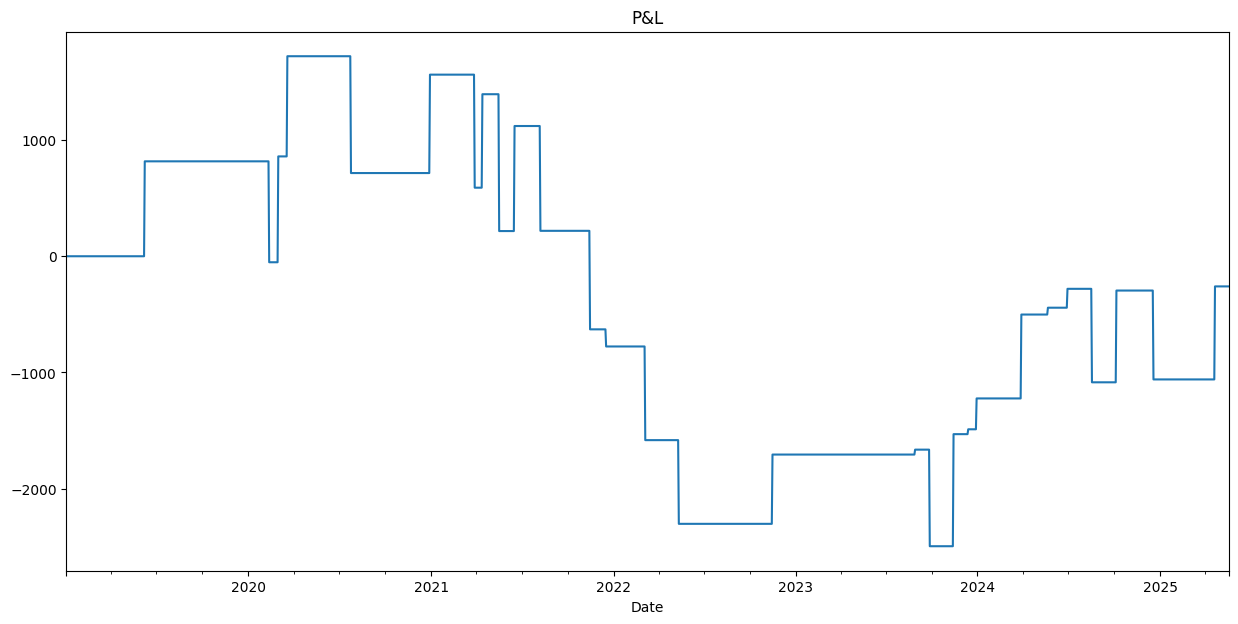

In [9]:

weights = [{'EMA': 0.2, 'MACD': 0.2, 'RSI': 0.2, 'SO': 0.2, 'PSAR': 0.1, 'BB': 0.1},0.1,0.0165] 
backtester = Backtester(weights)
backtester.load_data('C:/Users/info/Downloads/trading_signals_project/data/fx/EUR_USD_B.xlsx', type='xlsx')
backtester.precompute_indicators()
backtester.select_indicators()  
backtester.generate_signals()   
backtester.run_backtest(3,3)
results = backtester.analyze_performance()
results[2]['P&L'].plot(figsize=(15, 7),title='P&L')

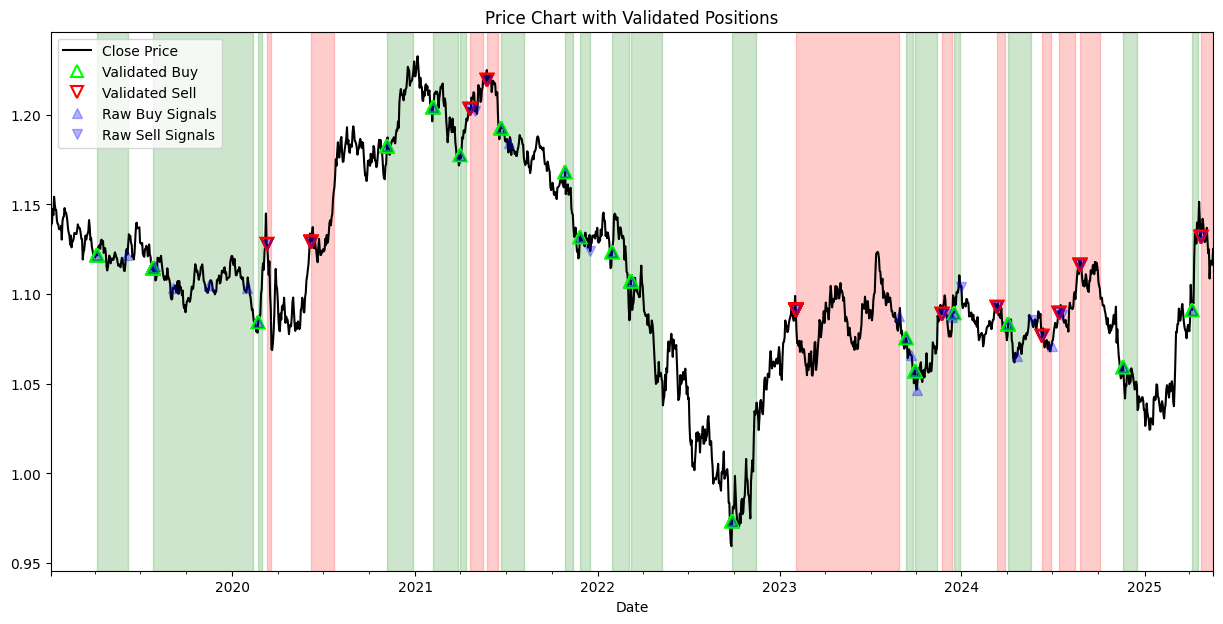

In [ ]:
backtester.plot_results()

### Optimizing Over `regime check` parameters 
- $\theta$ `Theta enter` parameter represents vote value threshold to consider valid signals
- $\epsilon$ `Eps trend` parameter represents value threshold to determine trend regime (Trendig or ranging)


In [12]:
# to test parameter influence :
param_grid = {
    'theta_enter' : np.linspace(0.1,0.6,6),
    'eps_trend' : np.linspace(0.01, 12,20)
}

theta_enter = param_grid['theta_enter']
eps_trend = param_grid['eps_trend']

tt, ep = np.meshgrid(theta_enter, eps_trend)
total_returns = np.zeros_like(tt)
# optimization loop
for i in range(tt.shape[0]):
    for j in range(tt.shape[1]):
        weights = [{'EMA': 0.2, 'MACD': 0.2, 'RSI': 0.2, 'SO': 0.2, 'PSAR': 0.1, 'BB': 0.1},tt[i, j],ep[i,j]] 
        bt = Backtester(weights)
        bt.load_data('C:/Users/info/Downloads/trading_signals_project/data/fx/USD_JPY.csv', type='csv')
        bt.precompute_indicators()
        bt.confirmed_indicators = ['RSI', 'MACD', 'SO', 'SAR','BB', 'EMA']
        bt._generate_combined_signals()
        bt.generate_signals()
        bt.run_backtest(3,3)
        results = bt.analyze_performance()
        equity = results[0]['Equity'].values
        print(equity[-1] / equity[0] - 1)
        print(i,j)
        total_returns[i, j] = (equity[-1] / equity[0] - 1) *100

Signals generated: Primary indicator with confirmation check!


Rentabilité totale: 70.78%
Rentabilité Annuelle: 15.70%
Drawdown maximum: -32.90%
Ratio de Sharpe: 0.52
Nombre de trades: 103
Last Pnl: 7077.54
Rentabilité du Buy & Hold: 35.34%
0.707754000000006
0 0
Signals generated: Primary indicator with confirmation check!
Rentabilité totale: -37.51%
Rentabilité Annuelle: -8.32%
Drawdown maximum: -58.32%
Ratio de Sharpe: -0.31
Nombre de trades: 67
Last Pnl: -3750.91
Rentabilité du Buy & Hold: 35.34%
-0.3750909999999985
0 1
Signals generated: Primary indicator with confirmation check!
Rentabilité totale: 2.06%
Rentabilité Annuelle: 0.46%
Drawdown maximum: -22.49%
Ratio de Sharpe: 0.08
Nombre de trades: 17
Last Pnl: 205.73
Rentabilité du Buy & Hold: 35.34%
0.020573000000001063
0 2
Signals generated: Primary indicator with confirmation check!
Rentabilité totale: -0.93%
Rentabilité Annuelle: -0.21%
Drawdown maximum: -8.84%
Ratio de Sharpe: 0.01
Nombre de trades: 4
Last Pnl: -93.20
Rentabilité du Buy & Hold: 35.34%
-0.009319999999999329
0 3
Signals gen

### Visualize optimization results


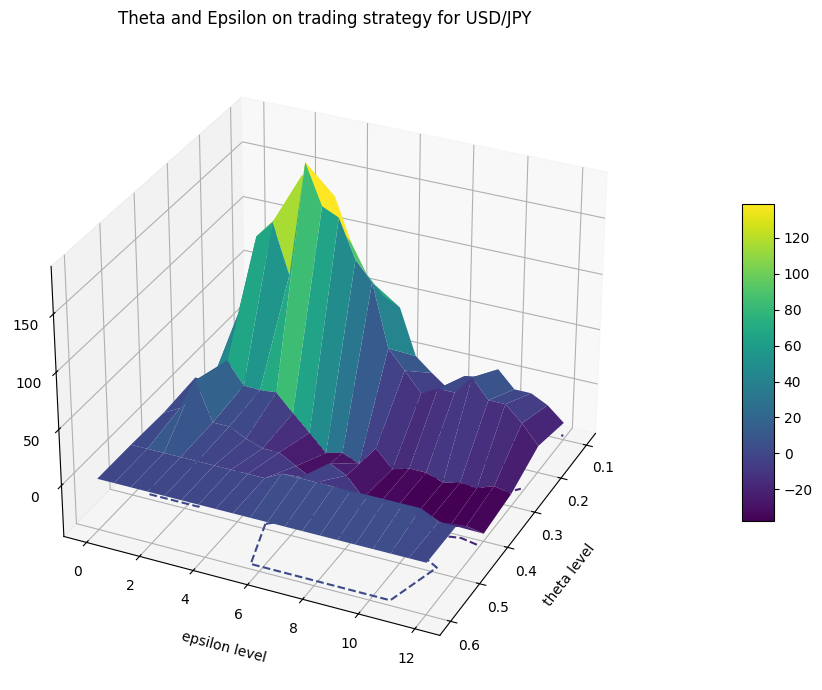

In [13]:
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(
    tt, ep, total_returns,
    cmap='viridis',
    edgecolor='none',
    rstride=1, cstride=1,
    antialiased=True
)
ax.contour(
    tt, ep, total_returns,
    zdir='z', offset=total_returns.min() - 0.01,
    cmap='viridis', linestyles='dashed'
)
ax.set_xlabel('theta level', labelpad=10)
ax.set_ylabel('epsilon level', labelpad=10)
ax.set_zlabel('Total Return (%)', labelpad=10)
ax.set_title('Theta and Epsilon on trading strategy for USD/JPY ', pad=15)
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10, pad=0.1)
ax.view_init(elev=30, azim=25)
plt.tight_layout()
plt.show()

In [14]:
# get best parameter set index
np.unravel_index(np.argmax(total_returns), total_returns.shape)

(np.int64(5), np.int64(1))

### Runs Backtest and generates `P&L` curve for different assets in a given folder

In [15]:
# Define plot_pairs function:
def plot_pairs(folderpath, figsize=(1400, 900), rows=4, cols=2):
    # This function plots P&L for multiple assets in a grid layout.
    csv_files = [
        f for f in os.listdir(folderpath)
        if f.endswith('.csv') or f.endswith('.xlsx')
    ]

    fig = make_subplots(
        rows=rows,
        cols=cols,
        subplot_titles=[os.path.splitext(f)[0] for f in csv_files],
        vertical_spacing=0.15,
        horizontal_spacing=0.1
    )
    # Iterate through each CSV file and process it
    for idx, filename in enumerate(csv_files):
        file_path = os.path.join(folderpath, filename)
    # Get the optimal parameters based on the filename
        if 'EUR' in filename:
            theta = 0.1
            eps = 0.0165
        elif 'AUD' in filename:
            theta = 0.1
            eps = 0.00336
        elif 'GBP' in filename:
            theta = 0.2
            eps = 0.0005
        elif 'NZD' in filename:
            theta = 0.1
            eps = 0.0027
        elif 'CAD' in filename:
            theta = 0.4
            eps = 0.0168
        elif 'CHF' in filename:
            theta = 0.2
            eps = 0.005
        elif 'JPY' in filename:
            theta = 0.1
            eps = 1.967
        weights = [
            {'EMA': 0.2, 'MACD': 0.2, 'RSI': 0.2, 'SO': 0.2, 'PSAR': 0.1, 'BB': 0.1},
            theta,
            eps
        ]
        bt = Backtester(weights)
        if filename.lower().endswith('.csv'):
            bt.load_data(file_path, type='csv')
        else:
            bt.load_data(file_path, type='xlsx')

        bt.precompute_indicators()
        bt.confirmed_indicators = ['RSI', 'MACD', 'SO', 'SAR', 'BB', 'EMA']
        bt._generate_combined_signals()
        bt.generate_signals()
        bt.run_backtest(3, 3)
        results = bt.analyze_performance()

        pnl_series = results[2]['P&L']
        pnl_series.index = pd.to_datetime(pnl_series.index)

        row = (idx // cols) + 1
        col = (idx % cols) + 1
        # Add P&L trace to the subplot
        fig.add_trace(
            go.Scatter(
                x=pnl_series.index,
                y=pnl_series.values,
                mode='lines+markers',
                line=dict(width=1),
                name=os.path.splitext(filename)[0]
            ),
            row=row,
            col=col
        )

    fig.update_layout(
        width=figsize[0],
        height=figsize[1],
        template='plotly_white',
        title_text='Backtest P&L per Asset Using Optimal Parameters',
        showlegend=False,
        margin=dict(t=80, b=50, l=50, r=50)
    )

    fig.update_xaxes(title_text='Date')
    fig.update_yaxes(title_text='P&L')

    fig.show()

In [16]:
plot_pairs('C:/Users/info/Downloads/trading_signals_project/data/fx')

Signals generated: Primary indicator with confirmation check!
Rentabilité totale: 218.01%
Rentabilité Annuelle: 48.33%
Drawdown maximum: -21.60%
Ratio de Sharpe: 1.01
Nombre de trades: 101
Last Pnl: 21801.30
Rentabilité du Buy & Hold: -11.10%
Signals generated: Primary indicator with confirmation check!
Rentabilité totale: 288.72%
Rentabilité Annuelle: 62.46%
Drawdown maximum: -24.36%
Ratio de Sharpe: 1.00
Nombre de trades: 113
Last Pnl: 28872.02
Rentabilité du Buy & Hold: -0.81%
Signals generated: Primary indicator with confirmation check!
Rentabilité totale: 136.83%
Rentabilité Annuelle: 30.33%
Drawdown maximum: -12.41%
Ratio de Sharpe: 0.86
Nombre de trades: 57
Last Pnl: 13682.92
Rentabilité du Buy & Hold: 1.31%
Signals generated: Primary indicator with confirmation check!
Rentabilité totale: 126.93%
Rentabilité Annuelle: 28.14%
Drawdown maximum: -32.30%
Ratio de Sharpe: 0.74
Nombre de trades: 120
Last Pnl: 12692.63
Rentabilité du Buy & Hold: -14.65%
Signals generated: Primary indic